In [4]:
# ============================================================
# Cell 2: Preprocessing — Flatten Features, 10 Classes
# ============================================================

from preprocessing.preprocess import preprocess

X_train, X_val, X_test, y_train, y_val, y_test = preprocess(
    feature_method='flatten',
    binary=False
)

y_train = y_train.astype(int)
y_val   = y_val.astype(int)
y_test  = y_test.astype(int)

N_CLASSES = 10

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {sorted(set(y_train))}")

 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Multi-class

 Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 784)  y_tr   : (48000,)
   X_val  : (12000, 784)  y_val  : (12000,)
   X_test : 

In [5]:
# ============================================================
# Cell 3: Decision Tree Classifier — Multiclass From Scratch
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time

# ─────────────────────────────────────────────
# Node Structure
# ─────────────────────────────────────────────
class Node:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, *, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value

    def is_leaf(self):
        return self.value is not None


def majority_class(y, n_classes=10):
    return int(np.bincount(y, minlength=n_classes).argmax())


# ─────────────────────────────────────────────
# Vectorized Best Split — Multiclass Gini Index
# ─────────────────────────────────────────────
def best_split_fast(X, y, n_classes=10):
    """
    Multiclass Gini:
        Gini(D) = 1 - sum(p_k^2)

    Weighted Gini:
        (|L|/|D|)Gini(L) + (|R|/|D|)Gini(R)
    """

    n_samples, n_features = X.shape
    total_counts = np.bincount(y, minlength=n_classes)

    best_feature = None
    best_threshold = None
    best_gini_val = float('inf')

    for feat_idx in range(n_features):
        col = X[:, feat_idx]

        order = np.argsort(col, kind='mergesort')
        col_sorted = col[order]
        y_sorted = y[order]

        one_hot = np.zeros((n_samples, n_classes), dtype=np.int32)
        one_hot[np.arange(n_samples), y_sorted] = 1

        cum_counts = np.cumsum(one_hot, axis=0)

        left_counts = cum_counts[:-1]
        left_n = np.arange(1, n_samples)

        right_counts = total_counts - left_counts
        right_n = n_samples - left_n

        valid = col_sorted[:-1] != col_sorted[1:]

        if not np.any(valid):
            continue

        left_counts = left_counts[valid]
        right_counts = right_counts[valid]
        left_n_valid = left_n[valid]
        right_n_valid = right_n[valid]

        p_left = left_counts / left_n_valid[:, None]
        p_right = right_counts / right_n_valid[:, None]

        gini_left = 1.0 - np.sum(p_left ** 2, axis=1)
        gini_right = 1.0 - np.sum(p_right ** 2, axis=1)

        weighted = (
            left_n_valid * gini_left +
            right_n_valid * gini_right
        ) / n_samples

        best_idx = np.argmin(weighted)

        if weighted[best_idx] < best_gini_val:
            valid_positions = np.where(valid)[0]
            cut = valid_positions[best_idx]

            best_gini_val = weighted[best_idx]
            best_feature = feat_idx
            best_threshold = (col_sorted[cut] + col_sorted[cut + 1]) / 2.0

    return best_feature, best_threshold, best_gini_val


# ─────────────────────────────────────────────
# Recursive Tree Builder
# ─────────────────────────────────────────────
def build_tree(X, y, depth=0, max_depth=10, min_samples_split=30, n_classes=10):
    n_unique_classes = len(np.unique(y))

    if (
        n_unique_classes == 1 or
        depth >= max_depth or
        len(y) < min_samples_split
    ):
        return Node(value=majority_class(y, n_classes))

    feat, thresh, _ = best_split_fast(X, y, n_classes)

    if feat is None:
        return Node(value=majority_class(y, n_classes))

    left_mask = X[:, feat] <= thresh
    right_mask = ~left_mask

    if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
        return Node(value=majority_class(y, n_classes))

    return Node(
        feature=feat,
        threshold=thresh,
        left=build_tree(
            X[left_mask],
            y[left_mask],
            depth + 1,
            max_depth,
            min_samples_split,
            n_classes
        ),
        right=build_tree(
            X[right_mask],
            y[right_mask],
            depth + 1,
            max_depth,
            min_samples_split,
            n_classes
        )
    )


# ─────────────────────────────────────────────
# Prediction
# ─────────────────────────────────────────────
def predict_one(tree, x):
    node = tree

    while not node.is_leaf():
        node = node.left if x[node.feature] <= node.threshold else node.right

    return node.value


def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])


print("Cell 3 complete — Multiclass Decision Tree defined successfully.")

Cell 3 complete — Multiclass Decision Tree defined successfully.


In [6]:
# ============================================================
# Cell 4: Train Decision Tree — Flatten
# ============================================================

MAX_DEPTH = 10
MIN_SAMPLES_SPLIT = 30

print("=" * 55)
print("  TRAINING DECISION TREE — FLATTEN")
print("=" * 55)
print(f"   max_depth         : {MAX_DEPTH}")
print(f"   min_samples_split : {MIN_SAMPLES_SPLIT}")
print(f"   training samples  : {X_train.shape[0]}")
print(f"   features          : {X_train.shape[1]}")
print(f"   classes           : {N_CLASSES}")

t0 = time.time()

tree_flat = build_tree(
    X_train,
    y_train,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    n_classes=N_CLASSES
)

t1 = time.time()

print(f"\nTree built successfully in {t1 - t0:.1f} seconds!")


  TRAINING DECISION TREE — FLATTEN
   max_depth         : 10
   min_samples_split : 30
   training samples  : 48000
   features          : 784
   classes           : 10

Tree built successfully in 82.0 seconds!


       EVALUATION — FLATTEN

Validation Set — Flatten
   Accuracy        : 85.31%
   Macro Precision : 85.24%
   Macro Recall    : 85.12%
   Macro F1-Score  : 85.14%

   Per-Class F1:
      Class 0: 92.41%
      Class 1: 93.83%
      Class 2: 83.14%
      Class 3: 80.73%
      Class 4: 83.54%
      Class 5: 80.43%
      Class 6: 89.26%
      Class 7: 88.80%
      Class 8: 78.59%
      Class 9: 80.61%


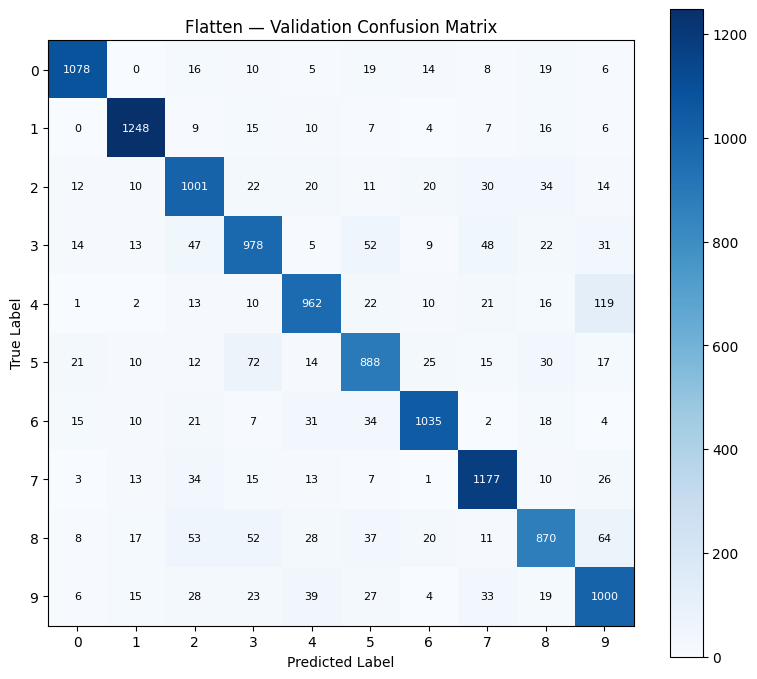


Test Set — Flatten
   Accuracy        : 86.07%
   Macro Precision : 85.90%
   Macro Recall    : 85.86%
   Macro F1-Score  : 85.87%

   Per-Class F1:
      Class 0: 92.21%
      Class 1: 95.39%
      Class 2: 84.62%
      Class 3: 84.17%
      Class 4: 82.95%
      Class 5: 81.25%
      Class 6: 87.48%
      Class 7: 89.42%
      Class 8: 79.58%
      Class 9: 81.59%


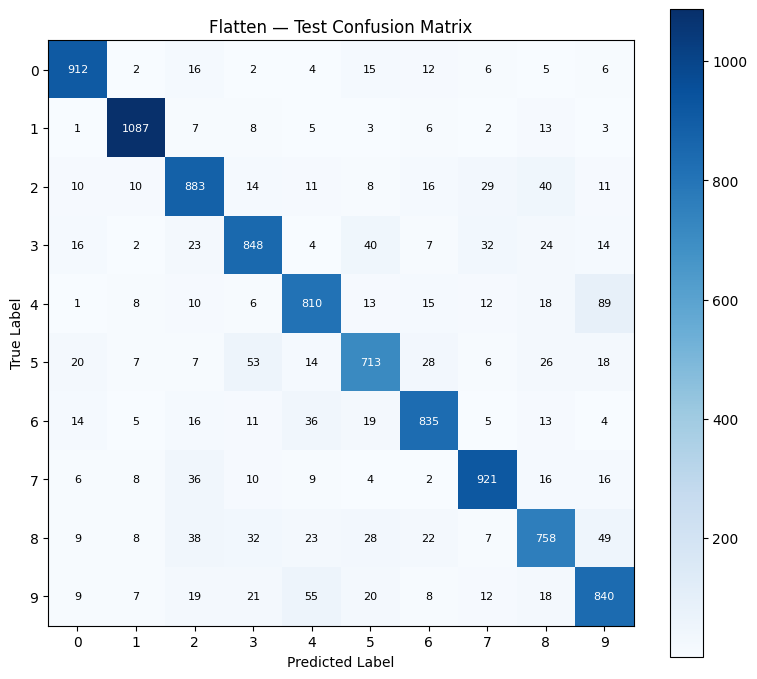


Majority-class baseline accuracy : 11.35%
Decision Tree Test Accuracy      : 86.07%
Improvement over baseline        : +74.72%

Train/Validation accuracy gap    : 4.13%
Diagnosis: acceptable bias-variance balance.

Cell 5 complete — Flatten Evaluation done!


In [7]:
# ============================================================
# Cell 5: Evaluation — Multiclass Metrics & Confusion Matrix
# ============================================================

def compute_metrics(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1

    accuracy = np.trace(cm) / np.sum(cm)

    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1 = np.zeros(n_classes)

    for c in range(n_classes):
        TP = cm[c, c]
        FP = np.sum(cm[:, c]) - TP
        FN = np.sum(cm[c, :]) - TP

        precision[c] = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall[c] = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        if precision[c] + recall[c] > 0:
            f1[c] = 2 * precision[c] * recall[c] / (precision[c] + recall[c])
        else:
            f1[c] = 0.0

    return {
        'accuracy': round(accuracy, 4),
        'precision': round(np.mean(precision), 4),
        'recall': round(np.mean(recall), 4),
        'f1': round(np.mean(f1), 4),
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1,
        'confusion_matrix': cm
    }


def print_metrics(metrics, split_name):
    print(f"\n{split_name}")
    print(f"   Accuracy        : {metrics['accuracy'] * 100:.2f}%")
    print(f"   Macro Precision : {metrics['precision'] * 100:.2f}%")
    print(f"   Macro Recall    : {metrics['recall'] * 100:.2f}%")
    print(f"   Macro F1-Score  : {metrics['f1'] * 100:.2f}%")

    print("\n   Per-Class F1:")
    for c in range(N_CLASSES):
        print(f"      Class {c}: {metrics['f1_per_class'][c] * 100:.2f}%")


def plot_confusion_matrix(metrics, title="Confusion Matrix"):
    cm = metrics['confusion_matrix']

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(N_CLASSES))
    ax.set_yticks(np.arange(N_CLASSES))
    ax.set_xticklabels(np.arange(N_CLASSES))
    ax.set_yticklabels(np.arange(N_CLASSES))

    thresh_color = cm.max() / 2

    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(
                j, i, str(cm[i, j]),
                ha='center',
                va='center',
                fontsize=8,
                color='white' if cm[i, j] > thresh_color else 'black'
            )

    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


print("=" * 55)
print("       EVALUATION — FLATTEN")
print("=" * 55)

y_train_pred_flat = predict(tree_flat, X_train)
y_val_pred_flat = predict(tree_flat, X_val)
y_test_pred_flat = predict(tree_flat, X_test)

train_metrics_flat = compute_metrics(y_train, y_train_pred_flat, N_CLASSES)
val_metrics_flat = compute_metrics(y_val, y_val_pred_flat, N_CLASSES)
test_metrics_flat = compute_metrics(y_test, y_test_pred_flat, N_CLASSES)

print_metrics(val_metrics_flat, "Validation Set — Flatten")
plot_confusion_matrix(val_metrics_flat, "Flatten — Validation Confusion Matrix")

print_metrics(test_metrics_flat, "Test Set — Flatten")
plot_confusion_matrix(test_metrics_flat, "Flatten — Test Confusion Matrix")

majority_class_label = majority_class(y_train, N_CLASSES)
baseline = np.mean(y_test == majority_class_label) * 100

print(f"\nMajority-class baseline accuracy : {baseline:.2f}%")
print(f"Decision Tree Test Accuracy      : {test_metrics_flat['accuracy'] * 100:.2f}%")
print(f"Improvement over baseline        : +{test_metrics_flat['accuracy'] * 100 - baseline:.2f}%")

gap = abs(train_metrics_flat['accuracy'] - val_metrics_flat['accuracy']) * 100
print(f"\nTrain/Validation accuracy gap    : {gap:.2f}%")

if gap > 5:
    print("Diagnosis: possible overfitting.")
else:
    print("Diagnosis: acceptable bias-variance balance.")

print("\nCell 5 complete — Flatten Evaluation done!")


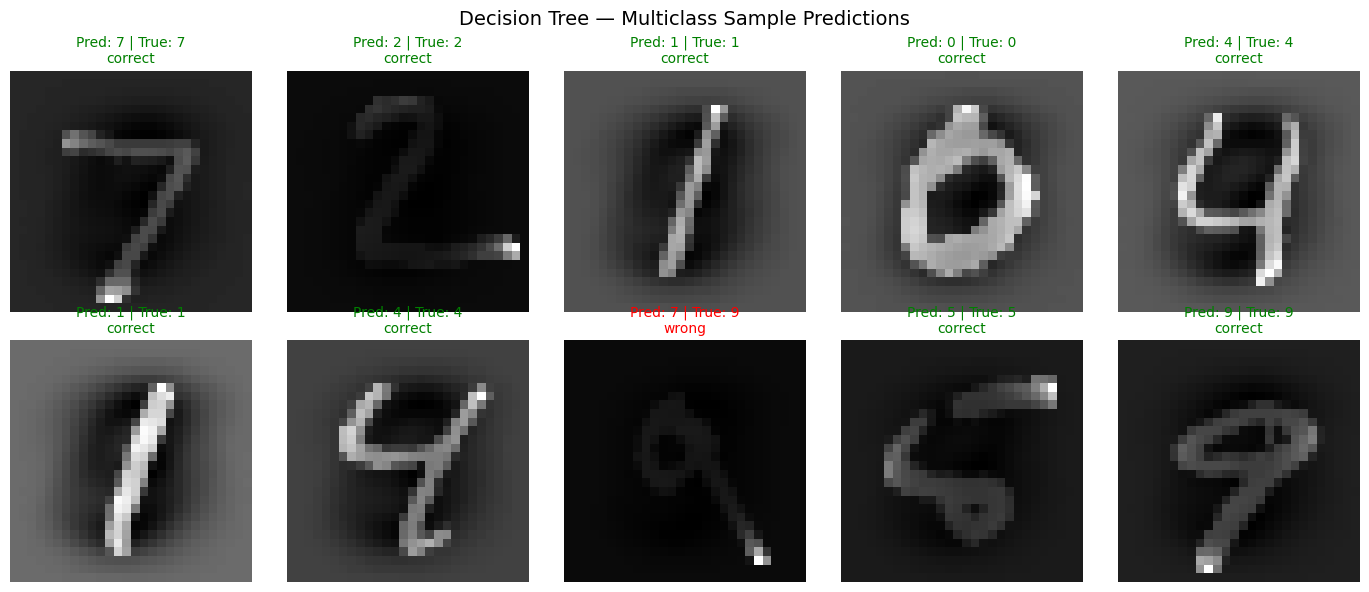


Cell 6 complete — Visual check done!


In [8]:
# ============================================================
# Cell 6: Visual Verification — Sample Predictions
# ============================================================

n_show = 10
X_vis = X_test[:n_show]
y_vis = y_test[:n_show]
y_pred_vis = predict(tree_flat, X_vis)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Decision Tree — Multiclass Sample Predictions", fontsize=14)

for i, ax in enumerate(axes.flatten()):
    img = X_vis[i].reshape(28, 28)
    img = (img - img.min()) / (img.max() - img.min())

    ax.imshow(img, cmap='gray')

    correct = y_pred_vis[i] == y_vis[i]
    color = 'green' if correct else 'red'
    label = 'correct' if correct else 'wrong'

    ax.set_title(
        f"Pred: {y_pred_vis[i]} | True: {y_vis[i]}\n{label}",
        color=color,
        fontsize=10
    )

    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nCell 6 complete — Visual check done!")

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 1.0000

 Preprocessing Pipeline Complete!
  

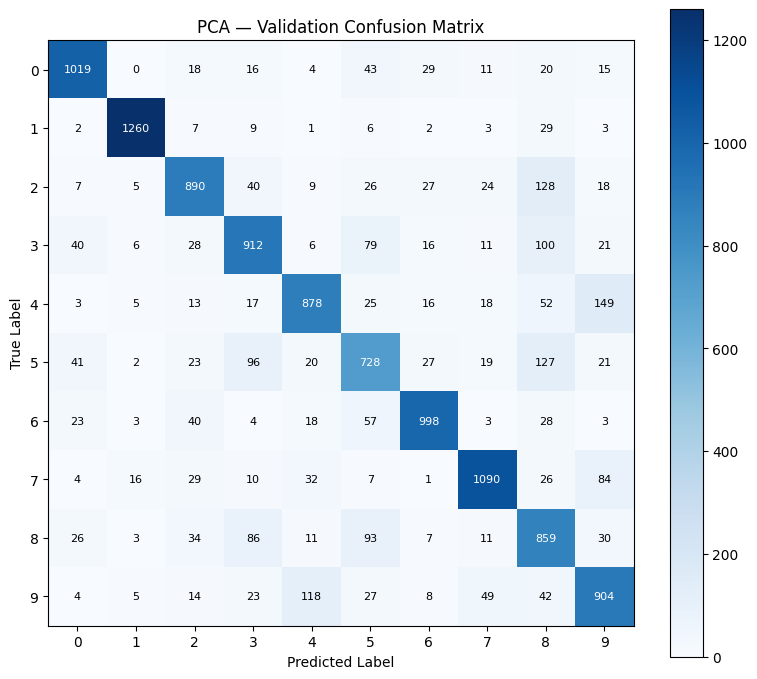


Test Set — PCA
   Accuracy        : 79.41%
   Macro Precision : 79.66%
   Macro Recall    : 79.10%
   Macro F1-Score  : 79.24%

   Per-Class F1:
      Class 0: 85.02%
      Class 1: 96.22%
      Class 2: 77.54%
      Class 3: 75.70%
      Class 4: 77.52%
      Class 5: 66.41%
      Class 6: 87.14%
      Class 7: 84.03%
      Class 8: 65.78%
      Class 9: 77.05%


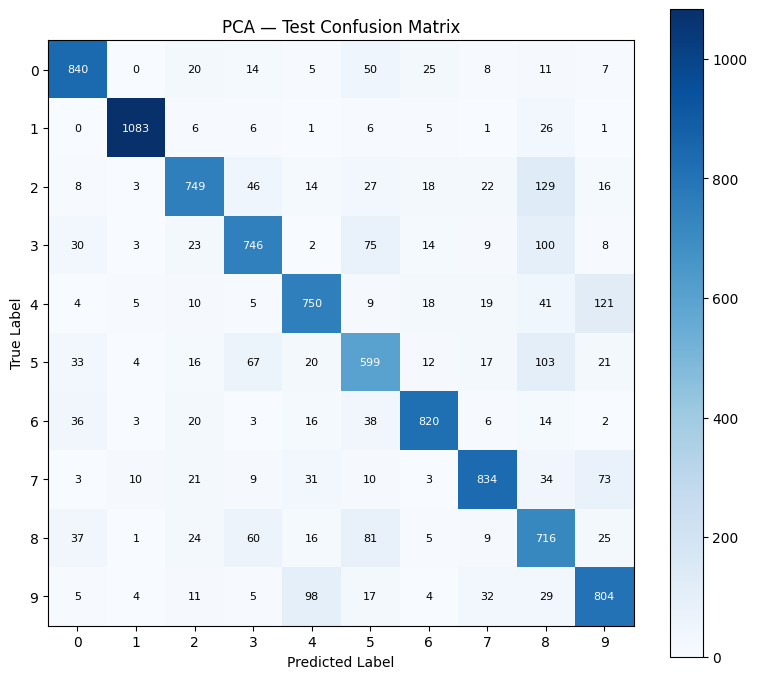


Train/Validation accuracy gap: 2.92%
Diagnosis: acceptable bias-variance balance.

PCA cell complete!


In [9]:
# ============================================================
# Cell 7: Decision Tree — Feature Method: PCA
# ============================================================

from preprocessing.preprocess import preprocess

X_train, X_val, X_test, y_train, y_val, y_test = preprocess(
    feature_method='pca',
    binary=False,
    pca_components=50
)

y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

print(f"Training set  : {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set      : {X_test.shape}")

print("\n" + "=" * 55)
print("  TRAINING — PCA Features")
print("=" * 55)

t0 = time.time()

tree_pca = build_tree(
    X_train,
    y_train,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    n_classes=N_CLASSES
)

t1 = time.time()

print(f"Tree built in {(t1 - t0) / 60:.1f} minutes!")

print("\n" + "=" * 55)
print("  EVALUATION — PCA Features")
print("=" * 55)

y_train_pred_pca = predict(tree_pca, X_train)
y_val_pred_pca = predict(tree_pca, X_val)
y_test_pred_pca = predict(tree_pca, X_test)

train_metrics_pca = compute_metrics(y_train, y_train_pred_pca, N_CLASSES)
val_metrics_pca = compute_metrics(y_val, y_val_pred_pca, N_CLASSES)
test_metrics_pca = compute_metrics(y_test, y_test_pred_pca, N_CLASSES)

print_metrics(val_metrics_pca, "Validation Set — PCA")
plot_confusion_matrix(val_metrics_pca, "PCA — Validation Confusion Matrix")

print_metrics(test_metrics_pca, "Test Set — PCA")
plot_confusion_matrix(test_metrics_pca, "PCA — Test Confusion Matrix")

gap = abs(train_metrics_pca['accuracy'] - val_metrics_pca['accuracy']) * 100

print(f"\nTrain/Validation accuracy gap: {gap:.2f}%")

if gap > 5:
    print("Diagnosis: possible overfitting.")
else:
    print("Diagnosis: acceptable bias-variance balance.")

print("\nPCA cell complete!")

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 0.9943

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 441)  y_tr   : (48000,)
   X_v

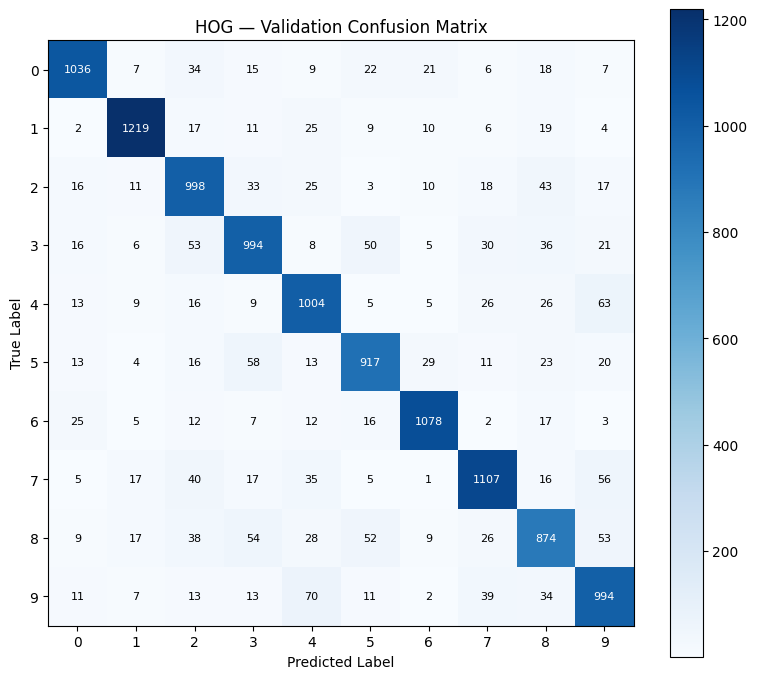


Test Set — HOG
   Accuracy        : 86.31%
   Macro Precision : 86.27%
   Macro Recall    : 86.17%
   Macro F1-Score  : 86.20%

   Per-Class F1:
      Class 0: 89.51%
      Class 1: 94.21%
      Class 2: 84.44%
      Class 3: 82.53%
      Class 4: 84.71%
      Class 5: 82.58%
      Class 6: 92.02%
      Class 7: 87.39%
      Class 8: 79.81%
      Class 9: 84.76%


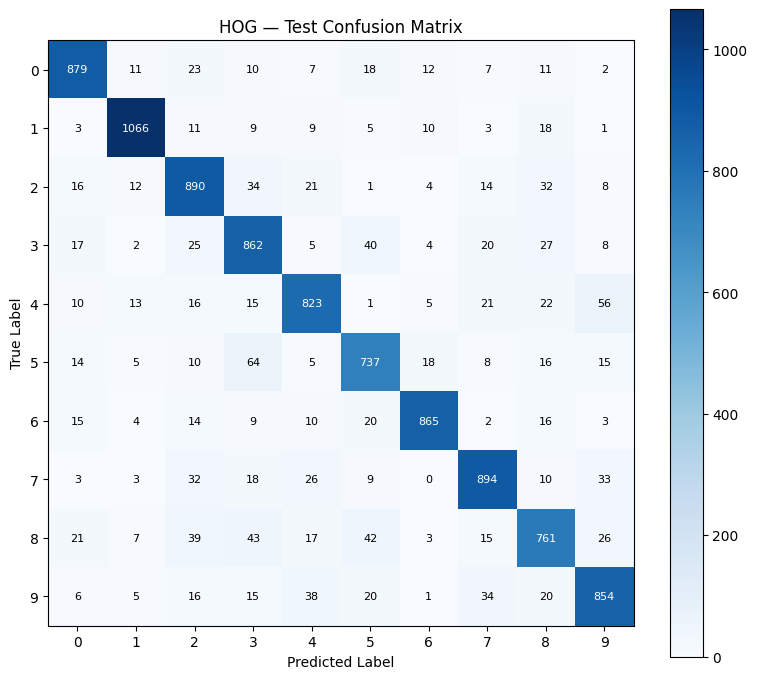


Train/Validation accuracy gap: 4.10%
Diagnosis: acceptable bias-variance balance.

HOG cell complete!


In [10]:
# ============================================================
# Cell 8: Decision Tree — Feature Method: HOG
# ============================================================

from preprocessing.preprocess import preprocess

X_train, X_val, X_test, y_train, y_val, y_test = preprocess(
    feature_method='hog',
    binary=False
)

y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

print(f"Training set  : {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set      : {X_test.shape}")

print("\n" + "=" * 55)
print("  TRAINING — HOG Features")
print("=" * 55)

t0 = time.time()

tree_hog = build_tree(
    X_train,
    y_train,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    n_classes=N_CLASSES
)

t1 = time.time()

print(f"Tree built in {(t1 - t0) / 60:.1f} minutes!")

print("\n" + "=" * 55)
print("  EVALUATION — HOG Features")
print("=" * 55)

y_train_pred_hog = predict(tree_hog, X_train)
y_val_pred_hog = predict(tree_hog, X_val)
y_test_pred_hog = predict(tree_hog, X_test)

train_metrics_hog = compute_metrics(y_train, y_train_pred_hog, N_CLASSES)
val_metrics_hog = compute_metrics(y_val, y_val_pred_hog, N_CLASSES)
test_metrics_hog = compute_metrics(y_test, y_test_pred_hog, N_CLASSES)

print_metrics(val_metrics_hog, "Validation Set — HOG")
plot_confusion_matrix(val_metrics_hog, "HOG — Validation Confusion Matrix")

print_metrics(test_metrics_hog, "Test Set — HOG")
plot_confusion_matrix(test_metrics_hog, "HOG — Test Confusion Matrix")

gap = abs(train_metrics_hog['accuracy'] - val_metrics_hog['accuracy']) * 100

print(f"\nTrain/Validation accuracy gap: {gap:.2f}%")

if gap > 5:
    print("Diagnosis: possible overfitting.")
else:
    print("Diagnosis: acceptable bias-variance balance.")

print("\nHOG cell complete!")

   DECISION TREE — MULTICLASS FEATURE METHOD COMPARISON
Method          Accuracy   Precision      Recall          F1
---------------------------------------------------------------------------
Flatten           86.07%      85.90%      85.86%      85.87%
PCA               79.41%      79.66%      79.10%      79.24%
HOG               86.31%      86.27%      86.17%      86.20%


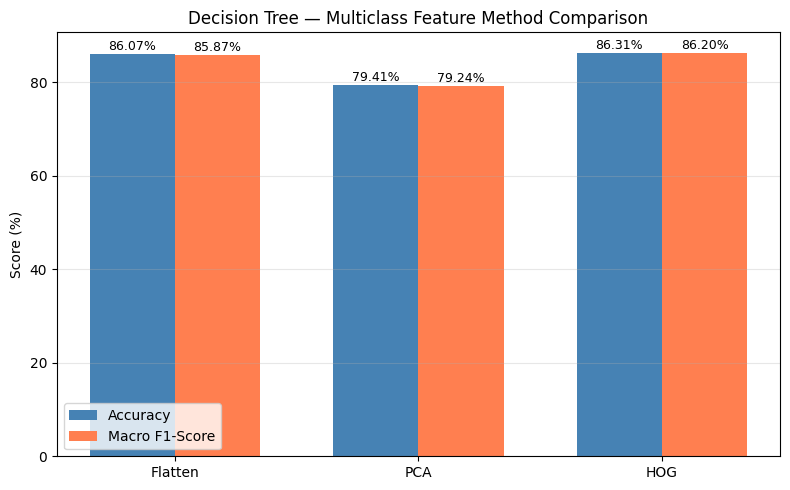


Cell 9 complete — Final comparison done!


In [11]:
# ============================================================
# Cell 9: Feature Method Comparison — Flatten vs PCA vs HOG
# ============================================================

print("=" * 75)
print("   DECISION TREE — MULTICLASS FEATURE METHOD COMPARISON")
print("=" * 75)

print(
    f"{'Method':<12}"
    f"{'Accuracy':>12}"
    f"{'Precision':>12}"
    f"{'Recall':>12}"
    f"{'F1':>12}"
)

print("-" * 75)

print(
    f"{'Flatten':<12}"
    f"{test_metrics_flat['accuracy'] * 100:>11.2f}%"
    f"{test_metrics_flat['precision'] * 100:>11.2f}%"
    f"{test_metrics_flat['recall'] * 100:>11.2f}%"
    f"{test_metrics_flat['f1'] * 100:>11.2f}%"
)

print(
    f"{'PCA':<12}"
    f"{test_metrics_pca['accuracy'] * 100:>11.2f}%"
    f"{test_metrics_pca['precision'] * 100:>11.2f}%"
    f"{test_metrics_pca['recall'] * 100:>11.2f}%"
    f"{test_metrics_pca['f1'] * 100:>11.2f}%"
)

print(
    f"{'HOG':<12}"
    f"{test_metrics_hog['accuracy'] * 100:>11.2f}%"
    f"{test_metrics_hog['precision'] * 100:>11.2f}%"
    f"{test_metrics_hog['recall'] * 100:>11.2f}%"
    f"{test_metrics_hog['f1'] * 100:>11.2f}%"
)

print("=" * 75)

methods = ['Flatten', 'PCA', 'HOG']

accuracies = [
    test_metrics_flat['accuracy'],
    test_metrics_pca['accuracy'],
    test_metrics_hog['accuracy']
]

f1_scores = [
    test_metrics_flat['f1'],
    test_metrics_pca['f1'],
    test_metrics_hog['f1']
]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width / 2,
    [a * 100 for a in accuracies],
    width,
    label='Accuracy',
    color='steelblue'
)

bars2 = ax.bar(
    x + width / 2,
    [f * 100 for f in f1_scores],
    width,
    label='Macro F1-Score',
    color='coral'
)

ax.set_ylabel('Score (%)')
ax.set_title('Decision Tree — Multiclass Feature Method Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.2f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.2f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("\nCell 9 complete — Final comparison done!")

In [12]:
# ============================================================
# Cell 10: Improvement 1 — Manual Hyperparameter Tuning with K-Fold CV
# ============================================================

print("=" * 70)
print("IMPROVEMENT 1 — HYPERPARAMETER TUNING WITH CROSS-VALIDATION")
print("=" * 70)

# Choose the best original feature method using validation accuracy
val_scores = {
    "flatten": val_metrics_flat["accuracy"],
    "pca": val_metrics_pca["accuracy"],
    "hog": val_metrics_hog["accuracy"]
}

best_feature_method = max(val_scores, key=val_scores.get)

print(f"Best feature method based on validation accuracy: {best_feature_method}")

if best_feature_method == "flatten":
    X_train_best, X_val_best, X_test_best, y_train_best, y_val_best, y_test_best = preprocess(
        feature_method='flatten',
        binary=False
    )

elif best_feature_method == "pca":
    X_train_best, X_val_best, X_test_best, y_train_best, y_val_best, y_test_best = preprocess(
        feature_method='pca',
        binary=False,
        pca_components=50
    )

else:
    X_train_best, X_val_best, X_test_best, y_train_best, y_val_best, y_test_best = preprocess(
        feature_method='hog',
        binary=False
    )

y_train_best = y_train_best.astype(int)
y_val_best = y_val_best.astype(int)
y_test_best = y_test_best.astype(int)

# ─────────────────────────────────────────────
# Use subset for CV speed
# Final model in Cell 11 still uses ALL training samples
# ─────────────────────────────────────────────
X_cv = X_train_best[:10000]
y_cv = y_train_best[:10000]

print(f"\nUsing {X_cv.shape[0]} samples for CV tuning.")
print("Final tuned model will still train on FULL training data.")

# ─────────────────────────────────────────────
# Manual K-Fold Split
# ─────────────────────────────────────────────
def make_k_folds(n_samples, k=3, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    fold_sizes = np.full(k, n_samples // k)
    fold_sizes[:n_samples % k] += 1

    folds = []
    start = 0

    for size in fold_sizes:
        end = start + size
        folds.append(indices[start:end])
        start = end

    return folds


# ─────────────────────────────────────────────
# Manual Cross-Validation
# ─────────────────────────────────────────────
def cross_validate_tree(X, y, params, k=3, n_classes=10):
    folds = make_k_folds(len(y), k=k)

    fold_accuracies = []
    fold_f1_scores = []

    for fold_id in range(k):
        val_idx = folds[fold_id]

        train_idx = np.concatenate([
            folds[j] for j in range(k) if j != fold_id
        ])

        print(f"      Fold {fold_id + 1}/{k}")

        t0 = time.time()

        model = build_tree(
            X[train_idx],
            y[train_idx],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            n_classes=n_classes
        )

        t1 = time.time()

        y_val_fold_pred = predict(model, X[val_idx])

        fold_metrics = compute_metrics(
            y[val_idx],
            y_val_fold_pred,
            n_classes
        )

        fold_accuracies.append(fold_metrics["accuracy"])
        fold_f1_scores.append(fold_metrics["f1"])

        print(f"         Accuracy : {fold_metrics['accuracy'] * 100:.2f}%")
        print(f"         F1-score : {fold_metrics['f1'] * 100:.2f}%")
        print(f"         Time     : {t1 - t0:.1f} seconds")

    return {
        "mean_accuracy": np.mean(fold_accuracies),
        "std_accuracy": np.std(fold_accuracies),
        "mean_f1": np.mean(fold_f1_scores),
        "std_f1": np.std(fold_f1_scores)
    }


param_grid = [
    {"max_depth": 8,  "min_samples_split": 40},
    {"max_depth": 10, "min_samples_split": 30},
    {"max_depth": 12, "min_samples_split": 20}
]

cv_results = []

K_FOLDS = 3

for params in param_grid:
    print("\nTesting hyperparameters:")
    print(f"   max_depth         : {params['max_depth']}")
    print(f"   min_samples_split : {params['min_samples_split']}")

    result = cross_validate_tree(
        X_cv,
        y_cv,
        params,
        k=K_FOLDS,
        n_classes=N_CLASSES
    )

    cv_results.append({
        "params": params,
        "mean_accuracy": result["mean_accuracy"],
        "std_accuracy": result["std_accuracy"],
        "mean_f1": result["mean_f1"],
        "std_f1": result["std_f1"]
    })

    print(f"   Mean CV Accuracy : {result['mean_accuracy'] * 100:.2f}%")
    print(f"   Std CV Accuracy  : {result['std_accuracy'] * 100:.2f}%")
    print(f"   Mean CV F1       : {result['mean_f1'] * 100:.2f}%")
    print(f"   Std CV F1        : {result['std_f1'] * 100:.2f}%")


best_cv_result = max(
    cv_results,
    key=lambda r: r["mean_accuracy"]
)

BEST_MAX_DEPTH = best_cv_result["params"]["max_depth"]
BEST_MIN_SAMPLES_SPLIT = best_cv_result["params"]["min_samples_split"]

print("\n" + "=" * 70)
print("BEST CROSS-VALIDATION RESULT")
print("=" * 70)

print(f"Best feature method  : {best_feature_method}")
print(f"Best max_depth       : {BEST_MAX_DEPTH}")
print(f"Best min_samples     : {BEST_MIN_SAMPLES_SPLIT}")
print(f"Mean CV Accuracy     : {best_cv_result['mean_accuracy'] * 100:.2f}%")
print(f"Mean CV F1-score     : {best_cv_result['mean_f1'] * 100:.2f}%")

print("=" * 70)

IMPROVEMENT 1 — HYPERPARAMETER TUNING WITH CROSS-VALIDATION
Best feature method based on validation accuracy: flatten
 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 784)  y_tr   

FINAL TUNED TREE — TRAINED ON ALL TRAINING SAMPLES
Final tuned tree trained in 109.0 seconds.

Training Set — Tuned Tree
   Accuracy        : 92.84%
   Macro Precision : 92.80%
   Macro Recall    : 92.75%
   Macro F1-Score  : 92.77%

   Per-Class F1:
      Class 0: 96.46%
      Class 1: 96.87%
      Class 2: 90.68%
      Class 3: 91.15%
      Class 4: 91.76%
      Class 5: 91.47%
      Class 6: 94.69%
      Class 7: 94.80%
      Class 8: 89.55%
      Class 9: 90.26%

Validation Set — Tuned Tree
   Accuracy        : 86.31%
   Macro Precision : 86.18%
   Macro Recall    : 86.13%
   Macro F1-Score  : 86.14%

   Per-Class F1:
      Class 0: 91.88%
      Class 1: 93.39%
      Class 2: 84.10%
      Class 3: 82.96%
      Class 4: 85.37%
      Class 5: 81.50%
      Class 6: 89.50%
      Class 7: 90.64%
      Class 8: 79.42%
      Class 9: 82.63%

Test Set — Tuned Tree
   Accuracy        : 87.52%
   Macro Precision : 87.38%
   Macro Recall    : 87.33%
   Macro F1-Score  : 87.34%

   Per-Class F

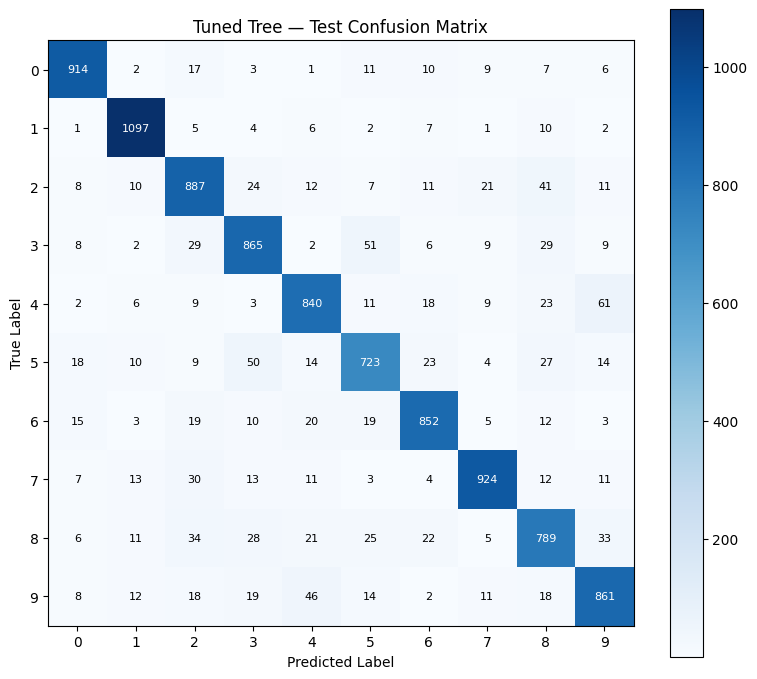

In [13]:
# ============================================================
# Cell 11: Train Final Tuned Tree on ALL Training Samples
# ============================================================

print("=" * 65)
print("FINAL TUNED TREE — TRAINED ON ALL TRAINING SAMPLES")
print("=" * 65)

t0 = time.time()

tree_tuned = build_tree(
    X_train_best,
    y_train_best,
    max_depth=BEST_MAX_DEPTH,
    min_samples_split=BEST_MIN_SAMPLES_SPLIT,
    n_classes=N_CLASSES
)

t1 = time.time()

print(f"Final tuned tree trained in {t1 - t0:.1f} seconds.")

y_train_pred_tuned = predict(tree_tuned, X_train_best)
y_val_pred_tuned = predict(tree_tuned, X_val_best)
y_test_pred_tuned = predict(tree_tuned, X_test_best)

train_metrics_tuned = compute_metrics(y_train_best, y_train_pred_tuned, N_CLASSES)
val_metrics_tuned = compute_metrics(y_val_best, y_val_pred_tuned, N_CLASSES)
test_metrics_tuned = compute_metrics(y_test_best, y_test_pred_tuned, N_CLASSES)

print_metrics(train_metrics_tuned, "Training Set — Tuned Tree")
print_metrics(val_metrics_tuned, "Validation Set — Tuned Tree")
print_metrics(test_metrics_tuned, "Test Set — Tuned Tree")

plot_confusion_matrix(test_metrics_tuned, "Tuned Tree — Test Confusion Matrix")

IMPROVEMENT 2 — BIAS-VARIANCE ANALYSIS

Training model with max_depth = 4
   Training Accuracy   : 55.36%
   Validation Accuracy : 55.76%
   Time                : 30.3 seconds

Training model with max_depth = 6
   Training Accuracy   : 73.69%
   Validation Accuracy : 72.93%
   Time                : 40.6 seconds

Training model with max_depth = 8
   Training Accuracy   : 83.21%
   Validation Accuracy : 80.90%
   Time                : 60.7 seconds

Training model with max_depth = 10
   Training Accuracy   : 89.99%
   Validation Accuracy : 85.54%
   Time                : 85.1 seconds

Training model with max_depth = 12
   Training Accuracy   : 92.84%
   Validation Accuracy : 86.31%
   Time                : 113.0 seconds


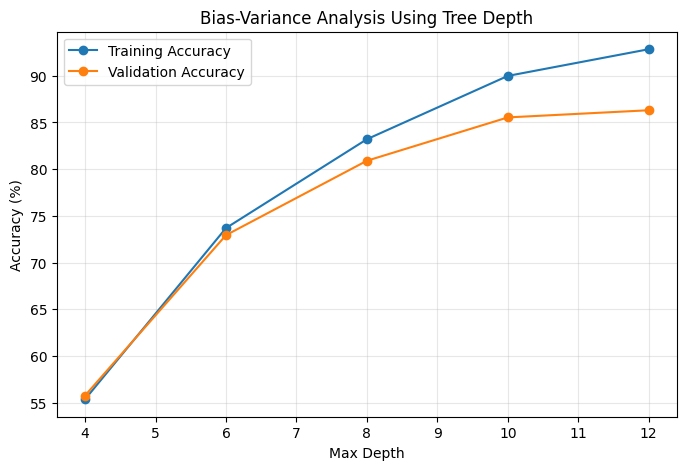


Final tuned train/validation gap: 6.53%
Diagnosis: possible overfitting.


In [14]:
# ============================================================
# Cell 12: Improvement 2 — Bias-Variance Analysis
# ============================================================

print("=" * 65)
print("IMPROVEMENT 2 — BIAS-VARIANCE ANALYSIS")
print("=" * 65)

depth_values = [4, 6, 8, 10, 12]

train_accs = []
val_accs = []

for depth in depth_values:
    print(f"\nTraining model with max_depth = {depth}")

    t0 = time.time()

    model = build_tree(
        X_train_best,
        y_train_best,
        max_depth=depth,
        min_samples_split=BEST_MIN_SAMPLES_SPLIT,
        n_classes=N_CLASSES
    )

    t1 = time.time()

    y_train_pred = predict(model, X_train_best)
    y_val_pred = predict(model, X_val_best)

    train_acc = np.mean(y_train_pred == y_train_best)
    val_acc = np.mean(y_val_pred == y_val_best)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"   Training Accuracy   : {train_acc * 100:.2f}%")
    print(f"   Validation Accuracy : {val_acc * 100:.2f}%")
    print(f"   Time                : {t1 - t0:.1f} seconds")

plt.figure(figsize=(8, 5))
plt.plot(depth_values, [a * 100 for a in train_accs], marker='o', label='Training Accuracy')
plt.plot(depth_values, [a * 100 for a in val_accs], marker='o', label='Validation Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy (%)")
plt.title("Bias-Variance Analysis Using Tree Depth")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

final_gap = abs(train_metrics_tuned["accuracy"] - val_metrics_tuned["accuracy"]) * 100
print(f"\nFinal tuned train/validation gap: {final_gap:.2f}%")

if final_gap > 5:
    print("Diagnosis: possible overfitting.")
else:
    print("Diagnosis: acceptable bias-variance balance.")

IMPROVEMENT 3 — MANUAL FEATURE-SUBSPACE ENSEMBLE

Total features available : 784
Features per tree        : 28

Training tree 1/5
   selected features : 28
   training samples  : 48000
   time: 3.8 seconds

Training tree 2/5
   selected features : 28
   training samples  : 48000
   time: 4.2 seconds

Training tree 3/5
   selected features : 28
   training samples  : 48000
   time: 4.6 seconds

Training tree 4/5
   selected features : 28
   training samples  : 48000
   time: 4.4 seconds

Training tree 5/5
   selected features : 28
   training samples  : 48000
   time: 5.3 seconds

Validation Set — Manual Ensemble
   Accuracy        : 81.58%
   Macro Precision : 81.70%
   Macro Recall    : 81.28%
   Macro F1-Score  : 81.11%

   Per-Class F1:
      Class 0: 88.39%
      Class 1: 89.28%
      Class 2: 84.14%
      Class 3: 77.61%
      Class 4: 78.72%
      Class 5: 75.80%
      Class 6: 89.23%
      Class 7: 84.79%
      Class 8: 71.39%
      Class 9: 71.80%

Test Set — Manual Ensemble
  

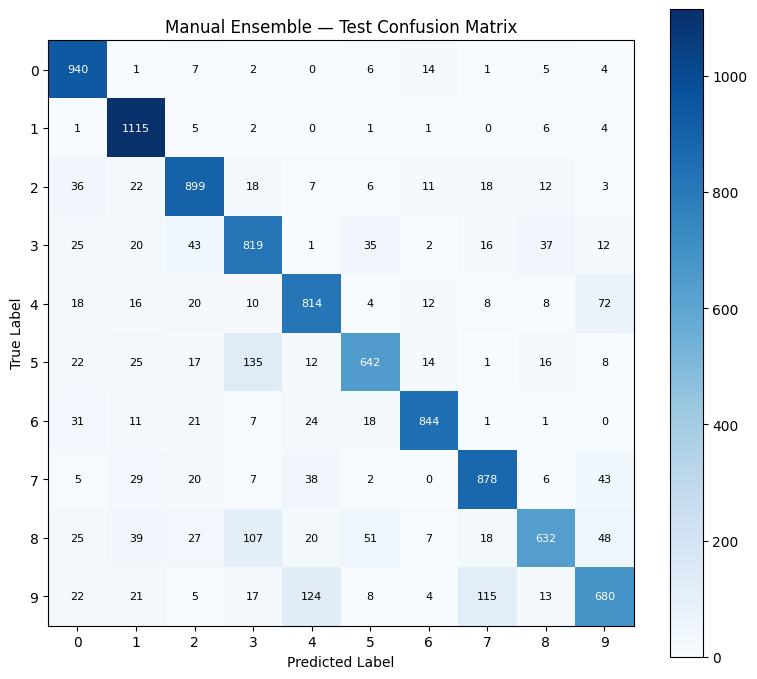

In [15]:
# ============================================================
# Cell 13: Improvement 3 — Manual Ensemble Method
# ============================================================

print("=" * 65)
print("IMPROVEMENT 3 — MANUAL FEATURE-SUBSPACE ENSEMBLE")
print("=" * 65)

def train_feature_subspace_forest(
    X,
    y,
    n_trees=5,
    max_features=25,
    max_depth=10,
    min_samples_split=30,
    n_classes=10,
    seed=42
):
    rng = np.random.default_rng(seed)

    forest = []

    n_total_features = X.shape[1]

    if max_features > n_total_features:
        max_features = n_total_features

    for i in range(n_trees):

        feature_indices = rng.choice(
            n_total_features,
            size=max_features,
            replace=False
        )

        print(f"\nTraining tree {i + 1}/{n_trees}")
        print(f"   selected features : {max_features}")
        print(f"   training samples  : {X.shape[0]}")

        t0 = time.time()

        tree = build_tree(
            X[:, feature_indices],
            y,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            n_classes=n_classes
        )

        t1 = time.time()

        forest.append({
            "tree": tree,
            "features": feature_indices
        })

        print(f"   time: {t1 - t0:.1f} seconds")

    return forest


def predict_forest(forest, X, n_classes=10):

    predictions = []

    for item in forest:

        tree = item["tree"]
        features = item["features"]

        preds = predict(tree, X[:, features])

        predictions.append(preds)

    predictions = np.array(predictions).T

    final_predictions = []

    for row in predictions:

        votes = np.bincount(row, minlength=n_classes)

        final_predictions.append(np.argmax(votes))

    return np.array(final_predictions)


N_TREES = 5

# Standard Random-Forest sqrt(feature_count) rule
MAX_FEATURES = min(
    int(np.sqrt(X_train_best.shape[1])),
    X_train_best.shape[1]
)

print(f"\nTotal features available : {X_train_best.shape[1]}")
print(f"Features per tree        : {MAX_FEATURES}")

forest = train_feature_subspace_forest(
    X_train_best,
    y_train_best,
    n_trees=N_TREES,
    max_features=MAX_FEATURES,
    max_depth=BEST_MAX_DEPTH,
    min_samples_split=BEST_MIN_SAMPLES_SPLIT,
    n_classes=N_CLASSES
)

y_val_pred_forest = predict_forest(
    forest,
    X_val_best,
    N_CLASSES
)

y_test_pred_forest = predict_forest(
    forest,
    X_test_best,
    N_CLASSES
)

val_metrics_forest = compute_metrics(
    y_val_best,
    y_val_pred_forest,
    N_CLASSES
)

test_metrics_forest = compute_metrics(
    y_test_best,
    y_test_pred_forest,
    N_CLASSES
)

print_metrics(
    val_metrics_forest,
    "Validation Set — Manual Ensemble"
)

print_metrics(
    test_metrics_forest,
    "Test Set — Manual Ensemble"
)

plot_confusion_matrix(
    test_metrics_forest,
    "Manual Ensemble — Test Confusion Matrix"
)

FINAL PHASE 2 COMPARISON
Model                                  Accuracy   Precision      Recall          F1
-------------------------------------------------------------------------------------
Best Original (HOG)                      86.31%      86.27%      86.17%      86.20%
Tuned Decision Tree                      87.52%      87.38%      87.33%      87.34%
Manual Ensemble                          82.63%      82.77%      82.30%      82.19%


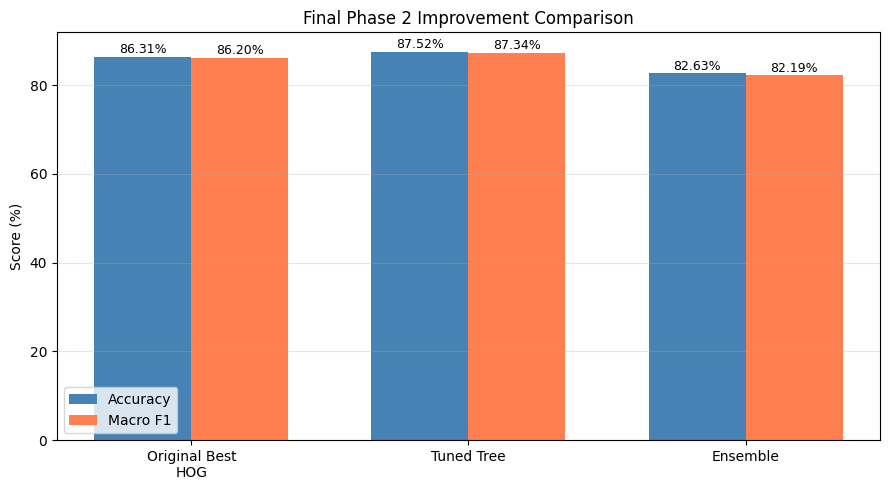


Phase 2 complete.


In [16]:
# ============================================================
# Cell 14: Final Phase 2 Comparison
# ============================================================

# Pick best original feature method as a complete model row
best_original_name, best_original = max(
    [
        ("Flatten", test_metrics_flat),
        ("PCA", test_metrics_pca),
        ("HOG", test_metrics_hog)
    ],
    key=lambda item: item[1]['accuracy']
)

print("=" * 85)
print("FINAL PHASE 2 COMPARISON")
print("=" * 85)

print(
    f"{'Model':<35}"
    f"{'Accuracy':>12}"
    f"{'Precision':>12}"
    f"{'Recall':>12}"
    f"{'F1':>12}"
)

print("-" * 85)

print(
    f"{'Best Original (' + best_original_name + ')':<35}"
    f"{best_original['accuracy'] * 100:>11.2f}%"
    f"{best_original['precision'] * 100:>11.2f}%"
    f"{best_original['recall'] * 100:>11.2f}%"
    f"{best_original['f1'] * 100:>11.2f}%"
)

print(
    f"{'Tuned Decision Tree':<35}"
    f"{test_metrics_tuned['accuracy'] * 100:>11.2f}%"
    f"{test_metrics_tuned['precision'] * 100:>11.2f}%"
    f"{test_metrics_tuned['recall'] * 100:>11.2f}%"
    f"{test_metrics_tuned['f1'] * 100:>11.2f}%"
)

print(
    f"{'Manual Ensemble':<35}"
    f"{test_metrics_forest['accuracy'] * 100:>11.2f}%"
    f"{test_metrics_forest['precision'] * 100:>11.2f}%"
    f"{test_metrics_forest['recall'] * 100:>11.2f}%"
    f"{test_metrics_forest['f1'] * 100:>11.2f}%"
)

print("=" * 85)

models = [
    "Original Best\n" + best_original_name,
    "Tuned Tree",
    "Ensemble"
]

accuracies = [
    best_original['accuracy'] * 100,
    test_metrics_tuned['accuracy'] * 100,
    test_metrics_forest['accuracy'] * 100
]

f1_scores = [
    best_original['f1'] * 100,
    test_metrics_tuned['f1'] * 100,
    test_metrics_forest['f1'] * 100
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width / 2,
    accuracies,
    width,
    label="Accuracy",
    color="steelblue"
)

bars2 = ax.bar(
    x + width / 2,
    f1_scores,
    width,
    label="Macro F1",
    color="coral"
)

ax.set_ylabel("Score (%)")
ax.set_title("Final Phase 2 Improvement Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.grid(axis="y", alpha=0.3)
ax.legend()

for bar in [*bars1, *bars2]:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("\nPhase 2 complete.")